In [1]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from numpy import asarray
from tqdm.notebook import tqdm


In [2]:
# аналогичным образом загружаем данные о пассажирах
passengers = pd.read_csv('passengers.csv')
# неподходящий формат данных приводим к тому, с которым Pandas может работать
passengers['Month'] = pd.to_datetime(passengers['Month'])
# также устанавливаем индекс и сортируем
df = passengers.set_index('Month').sort_index()

In [3]:
df

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


## Предсказание временного ряда с помощью деревьев

Попробуем обычное дерево решений и случайный лес, а потом сравним результаты

In [4]:
cols = []
for i in range(1, 0, -1):
    cols.append(df.shift(i))
cols

[            Passengers
 Month                 
 1949-01-01         NaN
 1949-02-01       112.0
 1949-03-01       118.0
 1949-04-01       132.0
 1949-05-01       129.0
 ...                ...
 1960-08-01       622.0
 1960-09-01       606.0
 1960-10-01       508.0
 1960-11-01       461.0
 1960-12-01       390.0
 
 [144 rows x 1 columns]]

In [5]:
cols = []
for i in range(1, 0, -1):
    cols.append(df.shift(i))
for i in range(0, 1):
    cols.append(df.shift(-i))
cols

[            Passengers
 Month                 
 1949-01-01         NaN
 1949-02-01       112.0
 1949-03-01       118.0
 1949-04-01       132.0
 1949-05-01       129.0
 ...                ...
 1960-08-01       622.0
 1960-09-01       606.0
 1960-10-01       508.0
 1960-11-01       461.0
 1960-12-01       390.0
 
 [144 rows x 1 columns],
             Passengers
 Month                 
 1949-01-01         112
 1949-02-01         118
 1949-03-01         132
 1949-04-01         129
 1949-05-01         121
 ...                ...
 1960-08-01         606
 1960-09-01         508
 1960-10-01         461
 1960-11-01         390
 1960-12-01         432
 
 [144 rows x 1 columns]]

In [6]:
agg = pd.concat(cols, axis=1)
agg.dropna(inplace=True)
agg

,Passengers,Passengers
Month,,
1949-02-01,112.0,118
1949-03-01,118.0,132
1949-04-01,132.0,129
1949-05-01,129.0,121
1949-06-01,121.0,135
...,...,...
1960-08-01,622.0,606
1960-09-01,606.0,508
1960-10-01,508.0,461


In [7]:
n_vars = 1 if type(df) is list else df.shape[1]
cols = []
for i in range(1, 0, -1):
    cols.append(df.shift(i))
for i in range(0, 1):
    cols.append(df.shift(-i))
# put it all together
agg = pd.concat(cols, axis=1)
agg.dropna(inplace=True)
list_for_forecast = agg.values

In [8]:
len(list_for_forecast)

143

In [9]:
def decision_tree_forecast(train, testX):
    train = asarray(train)
    trainX, trainy = train[:, :-1], train[:, -1]
    model = DecisionTreeRegressor(random_state=0)
    model.fit(trainX, trainy)
    yhat = model.predict([testX])
    return yhat[0]

In [10]:
def random_forest_forecast(train, testX):
    train = asarray(train)
    trainX, trainy = train[:, :-1], train[:, -1]
    model = RandomForestRegressor(n_estimators=1000)
    model.fit(trainX, trainy)
    yhat = model.predict([testX])
    return yhat[0]

In [11]:
predictions = []
size = int(len(list_for_forecast) * 0.66)
train, test = list_for_forecast[0:size], list_for_forecast[size:len(list_for_forecast)]
history = [x for x in train]
history

[array([112., 118.]),
 array([118., 132.]),
 array([132., 129.]),
 array([129., 121.]),
 array([121., 135.]),
 array([135., 148.]),
 array([148., 148.]),
 array([148., 136.]),
 array([136., 119.]),
 array([119., 104.]),
 array([104., 118.]),
 array([118., 115.]),
 array([115., 126.]),
 array([126., 141.]),
 array([141., 135.]),
 array([135., 125.]),
 array([125., 149.]),
 array([149., 170.]),
 array([170., 170.]),
 array([170., 158.]),
 array([158., 133.]),
 array([133., 114.]),
 array([114., 140.]),
 array([140., 145.]),
 array([145., 150.]),
 array([150., 178.]),
 array([178., 163.]),
 array([163., 172.]),
 array([172., 178.]),
 array([178., 199.]),
 array([199., 199.]),
 array([199., 184.]),
 array([184., 162.]),
 array([162., 146.]),
 array([146., 166.]),
 array([166., 171.]),
 array([171., 180.]),
 array([180., 193.]),
 array([193., 181.]),
 array([181., 183.]),
 array([183., 218.]),
 array([218., 230.]),
 array([230., 242.]),
 array([242., 209.]),
 array([209., 191.]),
 array([19

In [12]:
train.dtype(list())

TypeError: 'numpy.dtypes.Float64DType' object is not callable

In [12]:
predictions = []
size = int(len(list_for_forecast) * 0.66)
train, test = list_for_forecast[0:size], list_for_forecast[size:len(list_for_forecast)]
history = [x for x in train]

for i in tqdm(range(len(test)), desc="Random Forest: пошаговый прогноз", unit="месяц"):
    testX, testy = test[i, :-1], test[i, -1]
    yhat = random_forest_forecast(history, testX)
    predictions.append(yhat)
    history.append(test[i])

error = mean_absolute_error(test[:, -1], predictions)
print("Random Forest error: ", error)

Random Forest: пошаговый прогноз:   0%|          | 0/49 [00:00<?, ?месяц/s]

Random Forest error:  46.56737163913184


In [13]:
print("Random Forest metrics: ")
print("RMSE:", np.sqrt(mean_squared_error(test[:, -1], predictions)))
print("MAPE:", mean_absolute_percentage_error(test[:, -1], predictions))
print("MAE:", mean_absolute_error(test[:, -1], predictions))
print("R2: ", r2_score(test[:, -1], predictions))

Random Forest metrics: 
RMSE: 55.48311533735386
MAPE: 0.10951255972870885
MAE: 46.56737163913184
R2:  0.49875243980537853


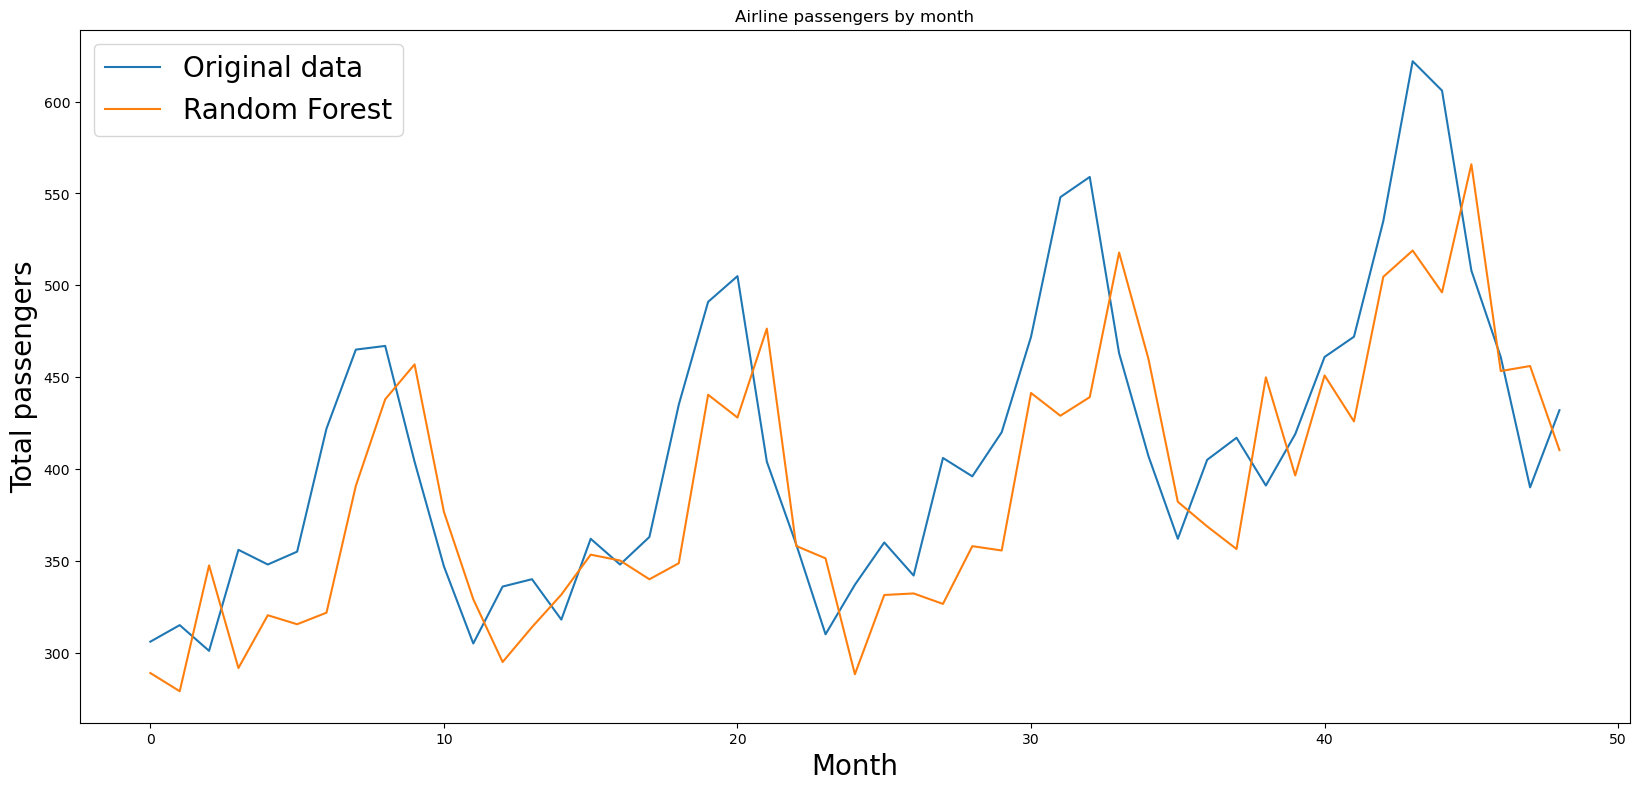

In [14]:
fig = plt.figure(figsize=(20, 9))
plt.plot(test[:, -1], label='Original data')
plt.plot(predictions, label='Random Forest')
plt.legend(fontsize="20")
plt.title('Airline passengers by month')
plt.ylabel('Total passengers', fontsize="20")
plt.xlabel('Month', fontsize="20")
plt.show()

In [15]:
predictions = list()
size = int(len(list_for_forecast) * 0.66)
train, test = list_for_forecast[0:size], list_for_forecast[size:len(list_for_forecast)]
history = [x for x in train]

for i in tqdm(range(len(test)), desc="Decision Tree: пошаговый прогноз", unit="месяц"):
    testX, testy = test[i, :-1], test[i, -1]
    yhat = decision_tree_forecast(history, testX)
    predictions.append(yhat)
    history.append(test[i])


Decision Tree: пошаговый прогноз:   0%|          | 0/49 [00:00<?, ?месяц/s]

In [16]:
print("Decision Forest metrics: ")
print("RMSE:", np.sqrt(mean_squared_error(test[:, -1], predictions)))
print("MAPE:", mean_absolute_percentage_error(test[:, -1], predictions))
print("MAE:", mean_absolute_error(test[:, -1], predictions))
print("R2: ", r2_score(test[:, -1], predictions))

Decision Forest metrics: 
RMSE: 65.29403666867132
MAPE: 0.12270617535711836
MAE: 52.1530612244898
R2:  0.3058111520951716


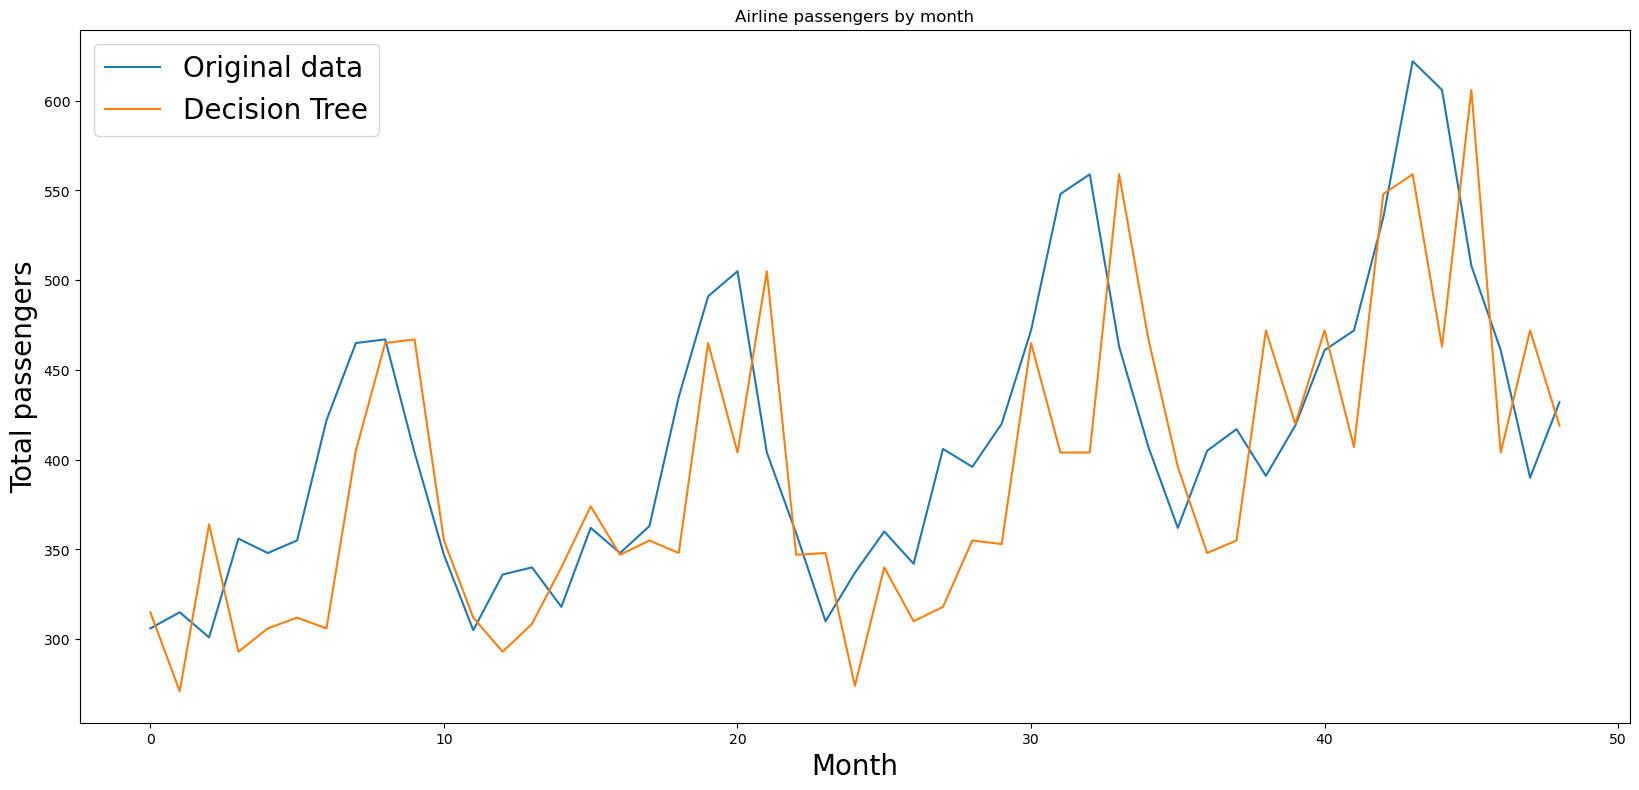

In [17]:
fig = plt.figure(figsize=(20, 9))
plt.plot(test[:, -1], label='Original data')
plt.plot(predictions, label='Decision Tree')
plt.legend(fontsize="20")
plt.title('Airline passengers by month')
plt.ylabel('Total passengers', fontsize="20")
plt.xlabel('Month', fontsize="20")
plt.show()

## Детекция аномалий с помощью isolated forest

In [18]:
from sklearn.ensemble import IsolationForest

In [19]:
# аналогичным образом загружаем данные о пассажирах
pas = pd.read_csv('passengers.csv')
# неподходящий формат данных приводим к тому, с которым Pandas может работать
pas['Month'] = pd.to_datetime(passengers['Month'])
# также устанавливаем индекс и сортируем
pas

,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


In [20]:
model = IsolationForest(contamination=0.004)

# Isolation Forest обучается один раз, поэтому прогресс-бар завершится за один шаг
with tqdm(total=1, desc="Обучение Isolation Forest", unit="модель") as pbar:
    model.fit(pas[["Passengers"]])
    pbar.update(1)


Обучение Isolation Forest:   0%|          | 0/1 [00:00<?, ?модель/s]

In [21]:
pas['outliers'] = pd.Series(model.predict(pas[['Passengers']])).apply(lambda x: 'yes' if (x == -1) else 'no' )

In [22]:
pas.query('outliers=="yes"')

,Month,Passengers,outliers
138,1960-07-01,622,yes


In [23]:
fig = px.scatter(pas.reset_index(), x='Month', y='Passengers', color='outliers')
fig.update_xaxes(
    rangeslider_visible=True,
)
fig.show()

## Самостоятельная работа

**Задание 1: Учет сезонности (больше лагов)**
В нашем прошлом примере мы брали сдвиг всего на один месяц (`lag = 1`). В данных авиаперевозок есть очевидная годовая сезонность.
Измените код так, чтобы модель смотрела на 12 предыдущих месяцев одновременно. Сформируйте выборку, обучите `RandomForest` с помощью функции `random_forest_forecast` и выведите метрики. Сравните, как изменились результаты.


Размер сформированной выборки: (132, 13)
Количество признаков: 12
Количество целевых значений: 132


Random Forest с 12 лагами:   0%|          | 0/45 [00:00<?, ?месяц/s]


Random Forest с 12 лагами:
RMSE: 33.4220
MAPE: 6.2682%
MAE:  26.6890
R2:   0.8084

Random Forest с 1 лагом из исходного примера:
RMSE: 65.2940
MAPE: 12.2706%
MAE:  52.1531
R2:   0.3058


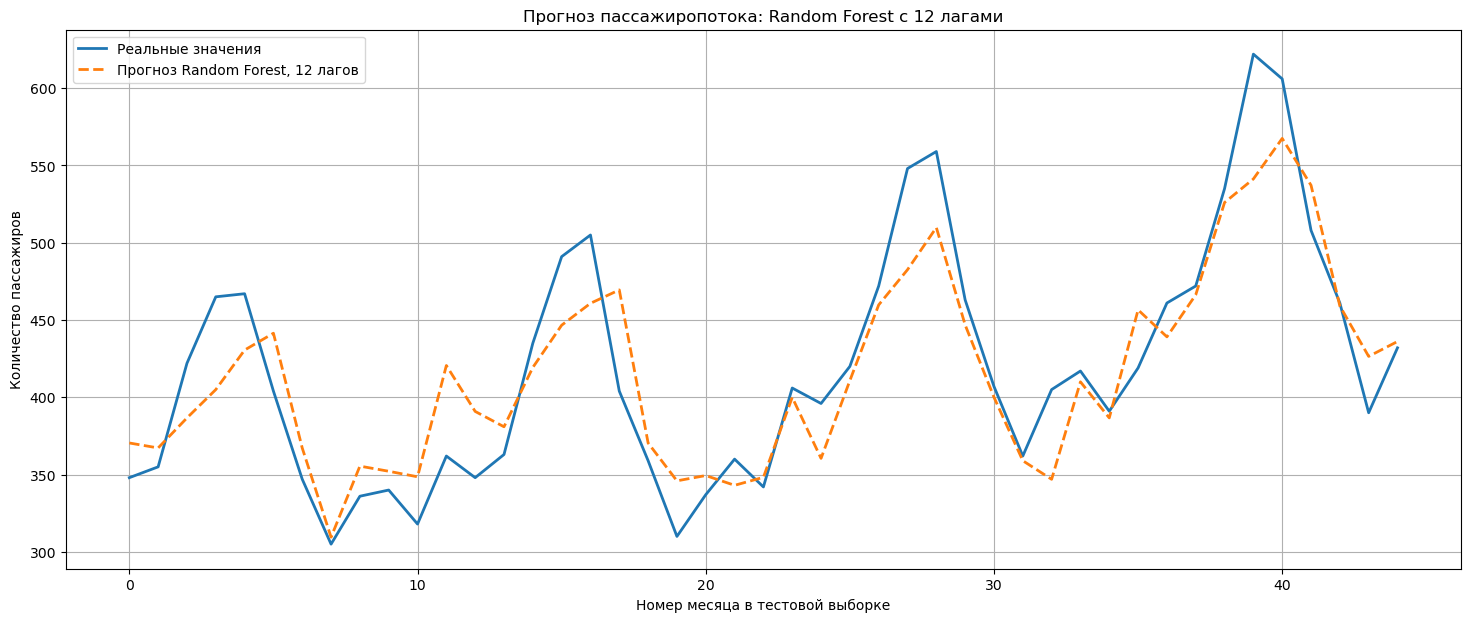

In [24]:
lag_count = 12
cols = []

for i in range(lag_count, 0, -1):
    cols.append(df.shift(i))

cols.append(df.shift(0))
agg_12 = pd.concat(cols, axis=1)
agg_12.dropna(inplace=True)
list_for_forecast_12 = agg_12.values
print("Размер сформированной выборки:", list_for_forecast_12.shape)
print("Количество признаков:", list_for_forecast_12.shape[1] - 1)
print("Количество целевых значений:", list_for_forecast_12.shape[0])
size_12 = int(len(list_for_forecast_12) * 0.66)
train_12 = list_for_forecast_12[:size_12]
test_12 = list_for_forecast_12[size_12:]
history_12 = [row for row in train_12]

rf_predictions_12 = []

for i in tqdm(range(len(test_12)), desc="Random Forest с 12 лагами", unit="месяц"):
    testX = test_12[i, :-1]
    testy = test_12[i, -1]
    yhat = random_forest_forecast(history_12, testX)
    rf_predictions_12.append(yhat)
    history_12.append(test_12[i])

actual_12 = test_12[:, -1]

rf_rmse_12 = np.sqrt(mean_squared_error(actual_12, rf_predictions_12))
rf_mape_12 = mean_absolute_percentage_error(actual_12, rf_predictions_12) * 100
rf_mae_12 = mean_absolute_error(actual_12, rf_predictions_12)
rf_r2_12 = r2_score(actual_12, rf_predictions_12)

print("\nRandom Forest с 12 лагами:")
print(f"RMSE: {rf_rmse_12:.4f}")
print(f"MAPE: {rf_mape_12:.4f}%")
print(f"MAE:  {rf_mae_12:.4f}")
print(f"R2:   {rf_r2_12:.4f}")

print("\nRandom Forest с 1 лагом из исходного примера:")
print(f"RMSE: {np.sqrt(mean_squared_error(test[:, -1], predictions)):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(test[:, -1], predictions) * 100:.4f}%")
print(f"MAE:  {mean_absolute_error(test[:, -1], predictions):.4f}")
print(f"R2:   {r2_score(test[:, -1], predictions):.4f}")

plt.figure(figsize=(18, 7))

plt.plot(
    actual_12,
    label="Реальные значения",
    linewidth=2
)

plt.plot(
    rf_predictions_12,
    label="Прогноз Random Forest, 12 лагов",
    linestyle="--",
    linewidth=2
)

plt.title("Прогноз пассажиропотока: Random Forest с 12 лагами")
plt.xlabel("Номер месяца в тестовой выборке")
plt.ylabel("Количество пассажиров")
plt.legend()
plt.grid(True)
plt.show()

**Задание 2: Сравнение деревьев с «глупым» бейзлайном (Naive Forecast)**
Чтобы понимать, насколько вообще полезно применять Random Forest, нужен ориентир (baseline). Напишите простую «наивную» модель: в качестве прогноза на следующий шаг берется просто значение предыдущего шага ($\hat{y}_t = y_{t-1}$).
Сравните $R^2$ и $MAE$ наивного прогноза с вашим лесом из Задания 1.

Сравнение моделей:


,Модель,MAE,RMSE,"MAPE, %",R2
0,Naive Forecast,40.9778,48.8717,9.7521,0.5903
1,"Random Forest, 12 лагов",26.6890,33.4220,6.2682,0.8084



По метрике MAE модель Random Forest работает лучше наивного прогноза.
По метрике R2 модель Random Forest лучше описывает изменчивость тестовой выборки.


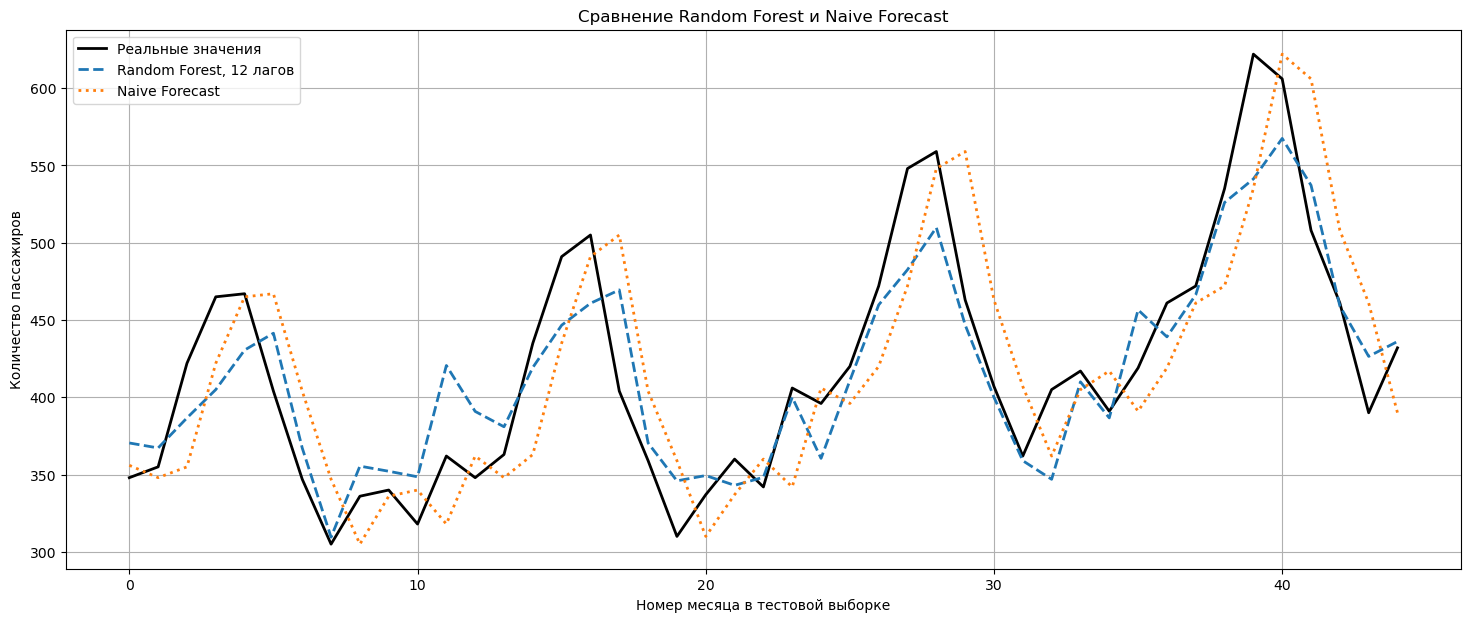

In [25]:
naive_predictions = test_12[:, -2]
actual_12 = test_12[:, -1]
naive_mae = mean_absolute_error(actual_12, naive_predictions)
naive_r2 = r2_score(actual_12, naive_predictions)
naive_rmse = np.sqrt(mean_squared_error(actual_12, naive_predictions))
naive_mape = mean_absolute_percentage_error(actual_12, naive_predictions) * 100
rf_mae = mean_absolute_error(actual_12, rf_predictions_12)
rf_r2 = r2_score(actual_12, rf_predictions_12)
rf_rmse = np.sqrt(mean_squared_error(actual_12, rf_predictions_12))
rf_mape = mean_absolute_percentage_error(actual_12, rf_predictions_12) * 100
comparison = pd.DataFrame({
    "Модель": ["Naive Forecast", "Random Forest, 12 лагов"],
    "MAE": [naive_mae, rf_mae],
    "RMSE": [naive_rmse, rf_rmse],
    "MAPE, %": [naive_mape, rf_mape],
    "R2": [naive_r2, rf_r2]
})

print("Сравнение моделей:")
display(comparison.round(4))
if rf_mae < naive_mae:
    print(
        "\nПо метрике MAE модель Random Forest работает лучше "
        "наивного прогноза."
    )
else:
    print(
        "\nПо метрике MAE наивный прогноз работает не хуже "
        "модели Random Forest."
    )
if rf_r2 > naive_r2:
    print(
        "По метрике R2 модель Random Forest лучше описывает "
        "изменчивость тестовой выборки."
    )
else:
    print(
        "По метрике R2 наивный прогноз показывает результат "
        "не хуже Random Forest."
    )
plt.figure(figsize=(18, 7))

plt.plot(
    actual_12,
    label="Реальные значения",
    color="black",
    linewidth=2
)

plt.plot(
    rf_predictions_12,
    label="Random Forest, 12 лагов",
    linestyle="--",
    linewidth=2
)

plt.plot(
    naive_predictions,
    label="Naive Forecast",
    linestyle=":",
    linewidth=2
)

plt.title("Сравнение Random Forest и Naive Forecast")
plt.xlabel("Номер месяца в тестовой выборке")
plt.ylabel("Количество пассажиров")
plt.legend()
plt.grid(True)
plt.show()

**Задание 3: Чувствительность алгоритма поиска аномалий**
В конце практики мы использовали алгоритм `IsolationForest` для поиска аномалий с крайне низким параметром `contamination=0.004`.
Измените этот параметр на `0.05` (поиск 5% самых аномальных периодов), обучите модель заново и отрисуйте график с новыми подсвеченными точками. Как поменялась картина, какие теперь месяцы считаются "нетипичными"?


In [26]:
from sklearn.ensemble import IsolationForest
pas_005 = pas[["Month", "Passengers"]].copy()
model_005 = IsolationForest(
    contamination=0.05,
    random_state=42
)

with tqdm(total=1, desc="Isolation Forest: contamination=0.05", unit="модель") as pbar:
    model_005.fit(pas_005[["Passengers"]])
    pbar.update(1)
pas_005["anomaly_label"] = model_005.predict(pas_005[["Passengers"]])
pas_005["outliers"] = pas_005["anomaly_label"].apply(
    lambda x: "yes" if x == -1 else "no"
)

anomalies_005 = pas_005.query('outliers == "yes"').copy()

print("Количество найденных аномальных месяцев:", len(anomalies_005))
print("\nМесяцы, признанные нетипичными:")
display(anomalies_005[["Month", "Passengers"]])

fig = px.scatter(
    pas_005,
    x="Month",
    y="Passengers",
    color="outliers",
    title="Поиск аномалий Isolation Forest при contamination = 0.05",
    labels={
        "Month": "Месяц",
        "Passengers": "Количество пассажиров",
        "outliers": "Аномалия"
    }
)

fig.update_xaxes(rangeslider_visible=True)
fig.show()

Isolation Forest: contamination=0.05:   0%|          | 0/1 [00:00<?, ?модель/s]

Количество найденных аномальных месяцев: 8

Месяцы, признанные нетипичными:


,Month,Passengers
10,1949-11-01,104
114,1958-07-01,491
126,1959-07-01,548
127,1959-08-01,559
137,1960-06-01,535
138,1960-07-01,622
139,1960-08-01,606
140,1960-09-01,508
